In [1]:
!pip install medmnist matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 106.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12

# Etapa 1 — Rede Neural do Zero com NumPy

Implementação completa de uma MLP usando **apenas NumPy**, incluindo:
- Forward propagation e Backpropagation com regra da cadeia matricial
- Otimizador SGD com Momentum
- Gradient Checking em duas camadas
- Curvas de loss/acurácia treino × validação

> **Dataset:** PathMNIST 28×28 (versão achatada para fins matemáticos, conforme enunciado)

In [2]:
# ============================================================
# CÉLULA 1 — Reprodutibilidade e Imports
# ============================================================
import numpy as np
import random

# Seed global fixada — obrigatório para reprodutibilidade (-10% sem isso)
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print(f"Seed fixada: {SEED}")
print("NumPy version:", np.__version__)

Seed fixada: 42
NumPy version: 2.4.6


In [3]:
# ============================================================
# CÉLULA 2 — Funções de Ativação e Perda
# ============================================================

class Ativacoes:
    """Funções de ativação e suas derivadas analíticas."""

    @staticmethod
    def relu(Z: np.ndarray) -> np.ndarray:
        return np.maximum(0, Z)

    @staticmethod
    def relu_derivada(Z: np.ndarray) -> np.ndarray:
        """Derivada de ReLU: 1 onde Z > 0, 0 caso contrário."""
        return (Z > 0).astype(np.float64)

    @staticmethod
    def softmax(Z: np.ndarray) -> np.ndarray:
        """Softmax numericamente estável: subtrai o máximo de cada linha antes do exp."""
        Z_shift = Z - np.max(Z, axis=1, keepdims=True)
        exp_Z = np.exp(Z_shift)
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)


class Perda:
    """Funções de perda."""

    @staticmethod
    def cross_entropy(y_pred: np.ndarray, y_true: np.ndarray) -> float:
        """
        Entropia cruzada categórica.
        y_pred: probabilidades preditas (N, C)
        y_true: one-hot encoding dos rótulos reais (N, C)
        """
        n = y_true.shape[0]
        # Clipping numérico para evitar log(0) → NaN
        y_pred_clip = np.clip(y_pred, 1e-12, 1.0 - 1e-12)
        return -np.sum(y_true * np.log(y_pred_clip)) / n

In [4]:
# ============================================================
# CÉLULA 3 — Camada Densa (Dense Layer)
# ============================================================

class CamadaDensa:
    """
    Camada totalmente conectada com otimizador SGD + Momentum embutido.

    Parâmetros
    ----------
    n_entradas  : dimensão da entrada
    n_neuronios : número de neurônios (unidades de saída)
    """

    def __init__(self, n_entradas: int, n_neuronios: int) -> None:
        # Inicialização He (Kaiming) — ideal para ReLU
        # Var(W) = 2 / n_entradas, evita explosão/desvanecimento de gradientes
        self.pesos  = np.random.randn(n_entradas, n_neuronios) * np.sqrt(2.0 / n_entradas)
        self.vieses = np.zeros((1, n_neuronios))

        # Acumuladores de velocidade para o Momentum (v_t), iniciados em zero
        self.v_pesos  = np.zeros_like(self.pesos)
        self.v_vieses = np.zeros_like(self.vieses)

        # Cache preenchido no forward e consumido no backward
        self.entrada: np.ndarray | None = None
        self.Z:       np.ndarray | None = None

    def forward(self, entrada: np.ndarray) -> np.ndarray:
        """Z = X · W + b"""
        self.entrada = entrada
        self.Z = np.dot(entrada, self.pesos) + self.vieses
        return self.Z

    def backward(
        self,
        dZ: np.ndarray,
        taxa_aprendizado: float,
        momentum: float,
    ) -> np.ndarray:
        """
        Regra da cadeia matricial + atualização SGD com Momentum.

        Fórmulas:
            dW  = (1/N) · Xᵀ · dZ
            db  = (1/N) · Σ dZ
            dX  = dZ · Wᵀ

        SGD com Momentum:
            v_t = β · v_{t-1} + η · ∇W
            W  ← W − v_t
        """
        n = self.entrada.shape[0]

        d_pesos  = np.dot(self.entrada.T, dZ) / n
        d_vieses = np.sum(dZ, axis=0, keepdims=True) / n
        d_entrada = np.dot(dZ, self.pesos.T)

        # Atualização com momentum
        self.v_pesos  = momentum * self.v_pesos  + taxa_aprendizado * d_pesos
        self.v_vieses = momentum * self.v_vieses + taxa_aprendizado * d_vieses

        self.pesos  -= self.v_pesos
        self.vieses -= self.v_vieses

        return d_entrada

In [5]:
# ============================================================
# CÉLULA 4 — MLP (Rede Neural Completa)
# ============================================================

class RedeNeuralMLP:
    """
    Perceptron Multicamadas genérico.
    Arquitetura: [Dense → ReLU] × (L-1) → Dense → Softmax
    """

    def __init__(self) -> None:
        self.camadas: list[CamadaDensa] = []

    def adicionar_camada(self, camada: CamadaDensa) -> None:
        self.camadas.append(camada)

    def forward(self, X: np.ndarray) -> np.ndarray:
        """Propagação direta: ReLU nas ocultas, Softmax na saída."""
        A = X
        for camada in self.camadas[:-1]:
            Z = camada.forward(A)
            A = Ativacoes.relu(Z)
        Z_saida = self.camadas[-1].forward(A)
        return Ativacoes.softmax(Z_saida)

    def backward(
        self,
        y_true: np.ndarray,
        y_pred: np.ndarray,
        taxa_aprendizado: float = 0.01,
        momentum: float = 0.9,
    ) -> None:
        """
        Retropropagação completa.
        Gradiente inicial: derivada de CE + Softmax = ŷ − y (forma compacta).
        """
        # Gradiente combinado Softmax + Cross-Entropy
        dZ = y_pred - y_true

        # Última camada (sem ativação intermediária)
        dA = self.camadas[-1].backward(dZ, taxa_aprendizado, momentum)

        # Camadas ocultas (de trás para frente)
        for camada in reversed(self.camadas[:-1]):
            dZ = dA * Ativacoes.relu_derivada(camada.Z)   # regra da cadeia
            dA = camada.backward(dZ, taxa_aprendizado, momentum)

In [6]:
# ============================================================
# CÉLULA 5 — Carregamento e Pré-processamento do PathMNIST 28×28
# ============================================================
from medmnist import PathMNIST

print("Carregando PathMNIST 28x28 (apenas para a Etapa NumPy)...")
train_dataset = PathMNIST(split="train", size=28, download=True)
val_dataset   = PathMNIST(split="val",   size=28, download=True)

# Achatar (N, 28, 28, 3) → (N, 2352) e normalizar para [0, 1]
X_train = train_dataset.imgs.reshape(len(train_dataset.imgs), -1).astype(np.float64) / 255.0
X_val   = val_dataset.imgs.reshape(len(val_dataset.imgs), -1).astype(np.float64)   / 255.0

# Rótulos inteiros (para acurácia) e one-hot (para a perda)
y_train_idx = train_dataset.labels.squeeze()
y_val_idx   = val_dataset.labels.squeeze()

NUM_CLASSES = 9
y_train_oh = np.eye(NUM_CLASSES)[y_train_idx]   # one-hot
y_val_oh   = np.eye(NUM_CLASSES)[y_val_idx]

print(f"X_train : {X_train.shape}  |  y_train : {y_train_oh.shape}")
print(f"X_val   : {X_val.shape}    |  y_val   : {y_val_oh.shape}")
print(f"Classes : {np.unique(y_train_idx)}")

Carregando PathMNIST 28x28 (apenas para a Etapa NumPy)...


100%|██████████| 206M/206M [00:16<00:00, 12.2MB/s]


X_train : (89996, 2352)  |  y_train : (89996, 9)
X_val   : (10004, 2352)    |  y_val   : (10004, 9)
Classes : [0 1 2 3 4 5 6 7 8]


In [7]:
# ============================================================
# CÉLULA 6 — Instanciação do Modelo e Loop de Treinamento
# ============================================================

# Hiperparâmetros
EPOCAS          = 15
TAXA_APRENDIZADO = 0.001
MOMENTUM        = 0.9
BATCH_SIZE      = 256

# Instancia modelo com seed já fixada acima
modelo = RedeNeuralMLP()
modelo.adicionar_camada(CamadaDensa(X_train.shape[1], 128))   # oculta
modelo.adicionar_camada(CamadaDensa(128, NUM_CLASSES))         # saída

# Historico de métricas para plot posterior
historico = {
    "train_loss": [],
    "val_loss":   [],
    "val_acc":    [],
}

print("\nIniciando treinamento do zero com NumPy...")
print(f"{'Época':>6}  {'Train Loss':>11}  {'Val Loss':>9}  {'Val Acc':>8}")
print("-" * 45)

for epoca in range(EPOCAS):
    # Embaralha a cada época
    perm = np.random.permutation(X_train.shape[0])
    X_sh = X_train[perm]
    y_sh = y_train_oh[perm]

    loss_treino_acum = 0.0
    n_batches = 0

    for i in range(0, X_train.shape[0], BATCH_SIZE):
        Xb = X_sh[i : i + BATCH_SIZE]
        yb = y_sh[i : i + BATCH_SIZE]

        preds = modelo.forward(Xb)
        modelo.backward(yb, preds, TAXA_APRENDIZADO, MOMENTUM)

        loss_treino_acum += Perda.cross_entropy(preds, yb)
        n_batches += 1

    # Loss média do treino (contagem exata de batches)
    train_loss = loss_treino_acum / n_batches

    # Avaliação na validação
    val_preds  = modelo.forward(X_val)
    val_loss   = Perda.cross_entropy(val_preds, y_val_oh)
    acertos    = np.sum(np.argmax(val_preds, axis=1) == y_val_idx)
    val_acc    = acertos / len(y_val_idx) * 100

    historico["train_loss"].append(train_loss)
    historico["val_loss"].append(val_loss)
    historico["val_acc"].append(val_acc)

    print(f"{epoca+1:>6}  {train_loss:>11.4f}  {val_loss:>9.4f}  {val_acc:>7.2f}%")

print("\n✅ Treinamento NumPy concluído!")
print(f"Melhor acurácia de validação: {max(historico['val_acc']):.2f}%")


Iniciando treinamento do zero com NumPy...
 Época   Train Loss   Val Loss   Val Acc
---------------------------------------------
     1       2.0320     1.9214    24.36%
     2       1.8688     1.8473    29.35%
     3       1.7988     1.7798    32.16%
     4       1.7404     1.7298    34.51%
     5       1.6930     1.6817    38.38%
     6       1.6563     1.6570    38.37%
     7       1.6260     1.6256    42.14%
     8       1.6022     1.6019    41.98%
     9       1.5829     1.5802    44.36%
    10       1.5603     1.5698    44.38%
    11       1.5437     1.5492    44.69%
    12       1.5291     1.5376    44.37%
    13       1.5146     1.5423    43.94%
    14       1.5006     1.5025    46.33%
    15       1.4867     1.4869    46.06%

✅ Treinamento NumPy concluído!
Melhor acurácia de validação: 46.33%


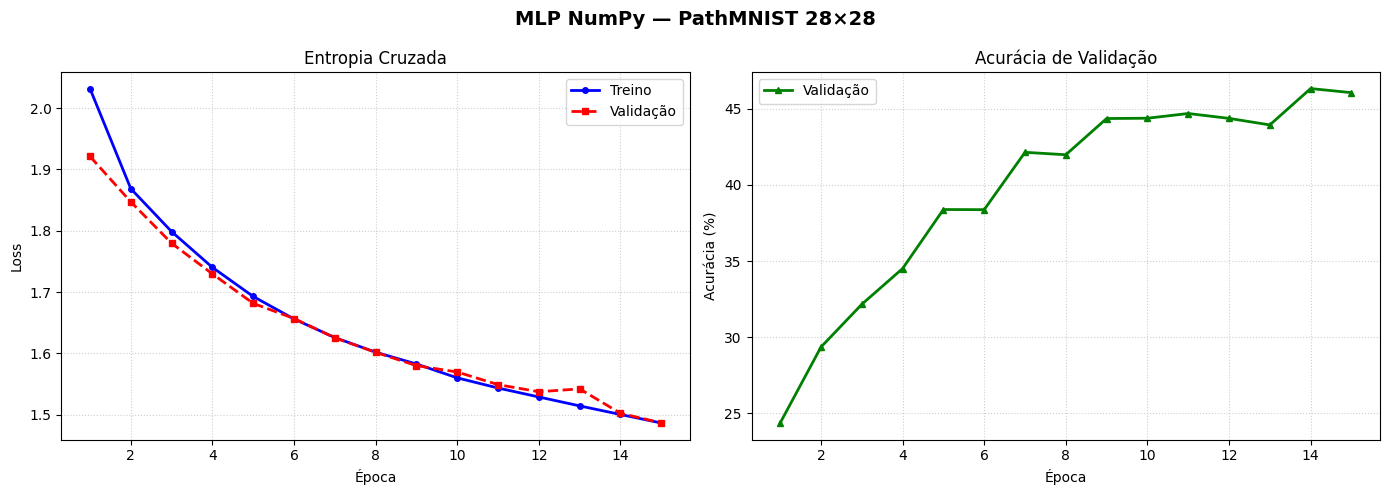

Figura salva: 01_numpy_mlp_curvas.png


In [8]:
# ============================================================
# CÉLULA 7 — Curvas de Loss e Acurácia (treino × validação)
# ============================================================
import matplotlib.pyplot as plt

epocas_eixo = range(1, EPOCAS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("MLP NumPy — PathMNIST 28×28", fontsize=14, fontweight="bold")

# Gráfico de Loss
axes[0].plot(epocas_eixo, historico["train_loss"], "b-o", label="Treino",    linewidth=2, markersize=4)
axes[0].plot(epocas_eixo, historico["val_loss"],   "r--s", label="Validação", linewidth=2, markersize=4)
axes[0].set_title("Entropia Cruzada")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico de Acurácia
axes[1].plot(epocas_eixo, historico["val_acc"], "g-^", label="Validação", linewidth=2, markersize=4)
axes[1].set_title("Acurácia de Validação")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Acurácia (%)")
axes[1].legend()
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig("01_numpy_mlp_curvas.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figura salva: 01_numpy_mlp_curvas.png")

In [9]:
# ============================================================
# CÉLULA 8 — Gradient Checking (camada oculta E camada de saída)
# ============================================================

def gradient_checking(
    rede: RedeNeuralMLP,
    X: np.ndarray,
    y: np.ndarray,
    idx_camada: int,
    n_check: int = 8,
    epsilon: float = 1e-7,
) -> float:
    """
    Compara o gradiente analítico (backprop) com a aproximação numérica
    pela diferença centrada: [f(W+ε) − f(W−ε)] / 2ε

    Retorna a diferença relativa.
    A diferença esperada é < 1e-5 para uma implementação correta.
    """
    camada = rede.camadas[idx_camada]

    # --- Gradiente analítico via backprop ---
    y_pred = rede.forward(X)
    dZ_saida = y_pred - y
    dA = rede.camadas[-1].backward.__func__   # não aplica; recalculamos abaixo

    # Recalcular sem alterar pesos: forward completo depois da última camada
    _ = rede.forward(X)   # garante cache atualizado
    dZ = (rede.forward(X) - y)
    # Propaga gradiente manualmente até a camada alvo
    dA = dZ
    for c in reversed(rede.camadas[idx_camada + 1:]):
        n_samp = c.entrada.shape[0]
        grad_w = np.dot(c.entrada.T, dA) / n_samp
        dA = np.dot(dA, c.pesos.T)
        if c is not rede.camadas[-1]:
            dA = dA * Ativacoes.relu_derivada(c.Z)

    if idx_camada < len(rede.camadas) - 1:
        dA = dA * Ativacoes.relu_derivada(camada.Z)

    n_samp = camada.entrada.shape[0]
    grad_analitico = np.dot(camada.entrada.T, dA) / n_samp

    # --- Gradiente numérico (diferença centrada) ---
    grad_numerico = np.zeros_like(camada.pesos)
    rows, cols = np.unravel_index(
        np.random.choice(camada.pesos.size, n_check, replace=False),
        camada.pesos.shape,
    )
    for i, j in zip(rows, cols):
        orig = camada.pesos[i, j]

        camada.pesos[i, j] = orig + epsilon
        loss_mais = Perda.cross_entropy(rede.forward(X), y)

        camada.pesos[i, j] = orig - epsilon
        loss_menos = Perda.cross_entropy(rede.forward(X), y)

        camada.pesos[i, j] = orig   # restaura
        grad_numerico[i, j] = (loss_mais - loss_menos) / (2 * epsilon)

    # Extrai somente os elementos verificados
    mask = grad_numerico != 0
    ga = grad_analitico[mask]
    gn = grad_numerico[mask]

    # Diferença relativa (norma de Frobenius)
    numerador   = np.linalg.norm(ga - gn)
    denominador = np.linalg.norm(ga) + np.linalg.norm(gn) + 1e-8
    diff        = numerador / denominador
    return diff


# --- Execução do teste em UMA REDE VIRGEM (antes de qualquer treino) ---
np.random.seed(SEED)   # garante reprodutibilidade do teste
X_gc = X_train[:5]
y_gc = y_train_oh[:5]

modelo_gc = RedeNeuralMLP()
modelo_gc.adicionar_camada(CamadaDensa(X_train.shape[1], 128))
modelo_gc.adicionar_camada(CamadaDensa(128, NUM_CLASSES))
_ = modelo_gc.forward(X_gc)   # preenche cache

print("=" * 55)
print(" GRADIENT CHECKING")
print("=" * 55)

for idx, nome in [(0, "Camada Oculta (0)"), (1, "Camada de Saída (1)")]:
    diff = gradient_checking(modelo_gc, X_gc, y_gc, idx_camada=idx)
    status = "✅ SUCESSO" if diff < 1e-5 else "❌ ALERTA"
    print(f"  {nome:25s} | Δ relativo = {diff:.3e}  {status}")

print("=" * 55)
print("Diferença esperada: < 1e-5 (conforme enunciado)")

 GRADIENT CHECKING
  Camada Oculta (0)         | Δ relativo = 1.677e-08  ✅ SUCESSO
  Camada de Saída (1)       | Δ relativo = 6.546e-09  ✅ SUCESSO
Diferença esperada: < 1e-5 (conforme enunciado)
